In [ ]:
!pip install cmdstanpy

from cmdstanpy import install_cmdstan
install_cmdstan()

CmdStan install directory: /root/.cmdstan
CmdStan version 2.38.0 already installed
Test model compilation


True

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from cmdstanpy import CmdStanModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

cali_house = pd.read_csv('/content/drive/Shareddrives/5440gaussian_process/5440gaussian_process/california_housing.csv')
cali_house.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### About the Dataset

This dataset contains housing data for various California districts, based on the 1990 U.S. Census. Each row represents a "block group" (a geographically compact area typically containing 600 to 3,000 people). Link: https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html

**Relevance to Gaussian Processes:** This dataset is an excellent candidate for demonstrating **Spatial Interpolation (Kriging)**. Instead of using all demographic features, we can isolate the geographic coordinates (`Longitude` and `Latitude`) to predict the median house value (`MedHouseVal`). A GP can model the spatial correlation of real estate markets, generating a smooth, non-linear topographical heatmap of housing prices across California, while simultaneously mapping out the predictive uncertainty in regions with sparse data.

#### Data Format (`california_housing.csv`) - (20640, 9)
The dataset combines demographic predictor features with geographic coordinates and the target housing value.

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| `MedInc` | Float | Median income in the block group. |
| `HouseAge` | Float | Median house age in the block group. |
| `AveRooms` | Float | Average number of rooms per household. |
| `AveBedrms` | Float | Average number of bedrooms per household. |
| `Population` | Float | Total block group population. |
| `AveOccup` | Float | Average number of household members. |
| `Latitude` | Float | **Spatial Input ($X_2$):** Block group latitude. |
| `Longitude` | Float | **Spatial Input ($X_1$):** Block group longitude. |
| `MedHouseVal` | Float | **Target Variable:** Median house value for California districts (expressed in hundreds of thousands of dollars, e.g., 4.526 = $452,600). |

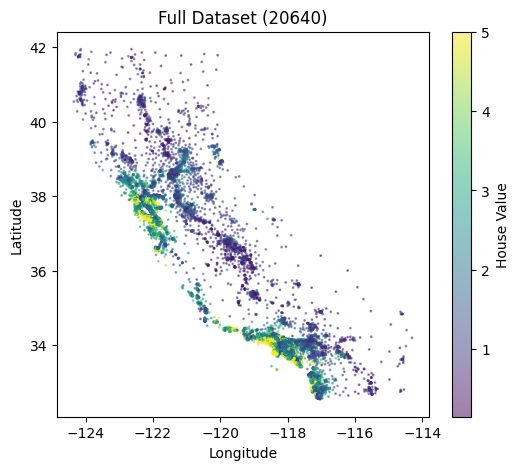

In [ ]:
vmin=cali_house['MedHouseVal'].min()
vmax=cali_house['MedHouseVal'].max()

plt.figure(figsize=(6,5))
plt.scatter(
    cali_house['Longitude'],
    cali_house['Latitude'],
    c=cali_house['MedHouseVal'],
    s=1,
    alpha=0.5,
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label='House Value')
plt.title('Full Dataset (20640)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

to better demenstrate the ability for Guassian Process (gp) to gain information with limited data, we sample 300 data points from the dataframe (use a smaller subset for Stan GP because exact GP with HMC is expensive) for both train and test, so actually 300*0.8 for learning

In [ ]:
df = cali_house[['Latitude', 'Longitude', 'MedHouseVal']].sample(300, random_state=42)
df.isna().sum()

,0
Latitude,0
Longitude,0
MedHouseVal,0


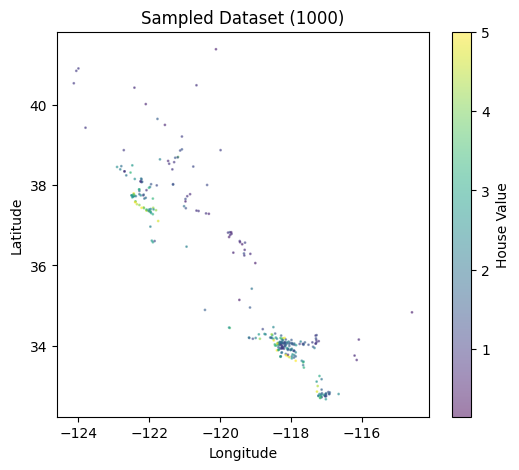

In [ ]:
vmin=cali_house['MedHouseVal'].min()
vmax=cali_house['MedHouseVal'].max()

plt.figure(figsize=(6,5))
plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['MedHouseVal'],
    s=1,
    alpha=0.5,
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label='House Value')
plt.title('Sampled Dataset (1000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
df_stan = df.reset_index(drop=True)

X = df_stan[['Latitude', 'Longitude']].to_numpy()
y = df_stan['MedHouseVal'].to_numpy()

print(X.shape, y.shape)

(300, 2) (300,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

now we need to standardize our data for gaussian process's sake

In [ ]:
# standardize inputs
from sklearn.preprocessing import StandardScaler
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# standardize target
y_mean = y_train.mean()
y_std = y_train.std()

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

The choice of kernel determines how similarity between inputs is defined. The RBF kernel assumes smooth variation and strong local correlation, making it appropriate for spatial data such as housing prices.

### Gaussian Process Regression Formulas

#### Model Specification:

#### Prior over functions
We place a Gaussian Process prior on the latent function:
$$
f(x) \sim \mathcal{GP}(0, k(x, x'))
$$

---

#### Observation model
Observations are modeled as:
$$
y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

---

#### Kernel function (RBF)
We use the radial basis function (RBF) kernel:
$$
k(x, x') = \alpha^2 \exp\left(-\frac{\|x - x'\|^2}{2\rho^2}\right)
$$

---

#### Joint Distribution

Let:
- $X$ denote training inputs
- $X_*$ denote test inputs

Then the joint distribution is:
$$
\begin{bmatrix}
y \\
f_*
\end{bmatrix}
\sim
\mathcal{N}
\left(
0,
\begin{bmatrix}
K(X,X) + \sigma^2 I & K(X, X_*) \\
K(X_*, X) & K(X_*, X_*)
\end{bmatrix}
\right)
$$

---

#### Covariance Matrices

We define:
$$
K = K(X,X) + \sigma^2 I
$$

$$
K_s = K(X, X_*)
$$

$$
K_{ss} = K(X_*, X_*)
$$

---

#### Posterior Predictive Distribution

Conditioning on observed data, the predictive distribution is:
$$
f_* \mid y \sim \mathcal{N}(\mu_*, \Sigma_*)
$$

---

#### Predictive mean
$$
\mu_* = K_s^T K^{-1} y
$$

---

#### Predictive covariance
$$
\Sigma_* = K_{ss} - K_s^T K^{-1} K_s
$$

---

#### Implementation Formulation

Instead of explicitly computing $K^{-1}$, we solve:
$$
\begin{aligned}
\alpha &= K^{-1} y \\
\mu_* &= K_s^T \alpha
\end{aligned}
$$

---

#### Posterior Predictive for Observations

Including observation noise:
$$
y_* \sim \mathcal{N}(\mu_*, \Sigma_* + \sigma^2 I)
$$

---

#### Posterior Predictive Sampling

We draw samples:
$$
y_*^{(s)} \sim \mathcal{N}(\mu_*, \Sigma_* + \sigma^2 I)
$$

---

#### Numerical Stabilization (Jitter)

To ensure numerical stability, we modify:
$$
K \leftarrow K + \epsilon I
$$

where $\epsilon$ is a small constant (e.g., $10^{-8}$).

---

#### Summary

Gaussian Process regression models the joint distribution of training and test outputs as a multivariate normal distribution. Predictions are obtained by conditioning this joint distribution, yielding closed-form expressions for both the predictive mean and uncertainty.

In [ ]:
stan_data = {
    'N_train': X_train_scaled.shape[0],
    'N_test': X_test_scaled.shape[0],
    'D': X_train_scaled.shape[1],
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train_scaled
}

model = CmdStanModel(stan_file='/content/drive/Shareddrives/5440gaussian_process/5440gaussian_process/gp_california.stan')

fit = model.sample(
    data=stan_data,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42
)

chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

Exception: cholesky_decompose: A is not symmetric. A[1,2] = -nan, but A[2,1] = -nan (in 'gp_california.stan', line 40, column 2 to column 30)
	Exception: cholesky_decompose: Matrix m is not positive definite (in 'gp_california.stan', line 40, column 2 to column 30)
Exception: cholesky_decompose: A is not symmetric. A[1,2] = -nan, but A[2,1] = -nan (in 'gp_california.stan', line 40, column 2 to column 30)
Consider re-running with show_console=True if the above output is unclear!


### Diagnostics

In [ ]:
summary_df = fit.summary()
print(summary_df.columns)

Index(['Mean', 'MCSE', 'StdDev', 'MAD', '5%', '50%', '95%', 'ESS_bulk',
       'ESS_tail', 'ESS_bulk/s', 'R_hat'],
      dtype='object')


In [ ]:
params = ['alpha', 'rho', 'sigma']
print(summary_df.loc[params, ['Mean', 'StdDev', 'R_hat', 'ESS_bulk', 'ESS_tail']])

           Mean    StdDev    R_hat  ESS_bulk  ESS_tail
alpha  0.918281  0.233114  1.00542  1158.900   663.511
rho    0.389081  0.290146  1.00602   750.555   801.452
sigma  0.772572  0.059097  1.00153  1049.910   922.148


In [ ]:
sampler_diagnostics = fit.diagnose()
print(sampler_diagnostics)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



now that seems pretty healthy - converged!

Posterior summaries

In [ ]:
posterior = fit.draws_pd()

params_of_interest = ['alpha', 'rho', 'sigma']
posterior_summary = summary_df.loc[
    params_of_interest,
    ['Mean', 'StdDev', '5%', '50%', '95%', 'R_hat']
]
print(posterior_summary)

           Mean    StdDev        5%       50%      95%    R_hat
alpha  0.918281  0.233114  0.651976  0.873101  1.32777  1.00542
rho    0.389081  0.290146  0.096951  0.299800  1.01812  1.00602
sigma  0.772572  0.059097  0.669029  0.774810  0.86445  1.00153


Visualize Posterior

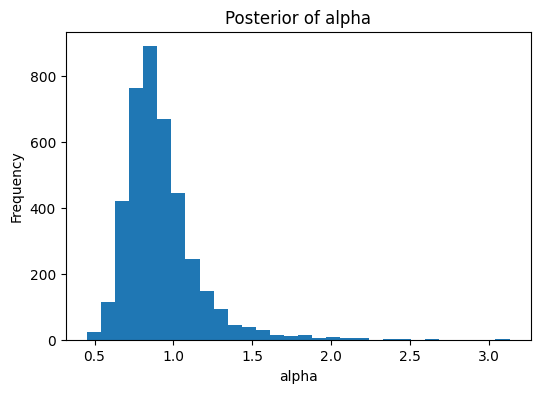

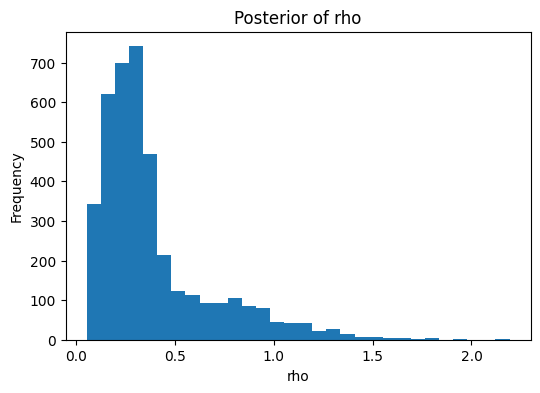

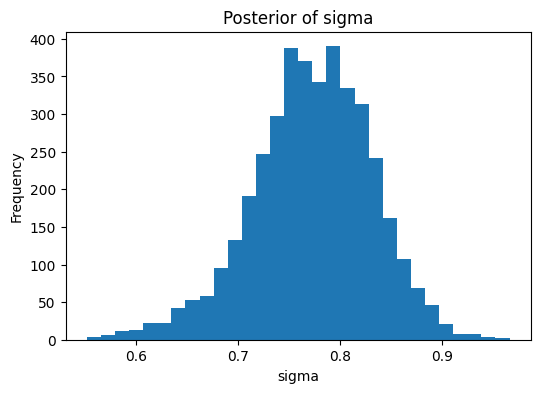

In [ ]:
for param in params_of_interest:
    plt.figure(figsize=(6, 4))
    plt.hist(posterior[param], bins=30)
    plt.title(f'Posterior of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency')
    plt.show()

Posterior predictive checks

In [ ]:
# Extract posterior predictive draws for test points
y_test_rep = fit.stan_variable('y_test_rep')   # shape: (draws, N_test)

# Posterior predictive mean on standardized scale
y_test_pred_mean_scaled = y_test_rep.mean(axis=0)

# Transform back to original scale
y_test_pred_mean = y_test_pred_mean_scaled * y_std + y_mean

#### Posterior Predictive Performance

predicted vs observed

The scatter plot of observed versus predicted values shows a positive relationship, indicating that the model captures some of the underlying structure in the data.

However, the predictions tend to be biased toward the mean: lower observed values are overestimated, while higher observed values are underestimated. This pattern suggests that the model is unable to fully capture the variability in housing prices.

This behavior is expected, as the model only uses spatial features (latitude and longitude) and does not incorporate other important predictors such as income, housing characteristics, or local economic factors.

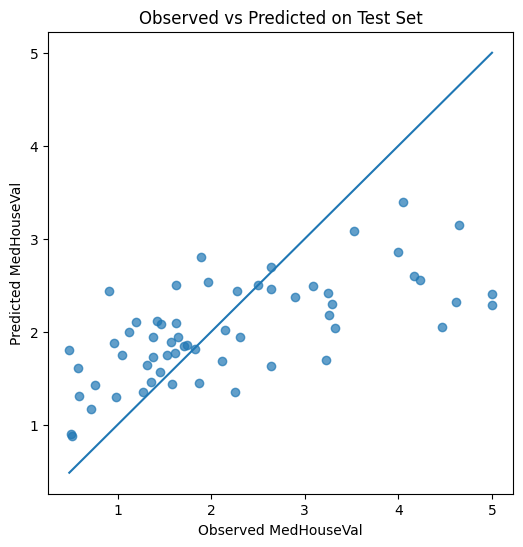

In [ ]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred_mean, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel('Observed MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Observed vs Predicted on Test Set')
plt.show()

#### Residual Analysis

The residuals are generally centered around zero, indicating that the model is approximately unbiased on average. However, the distribution exhibits a noticeable right tail, suggesting that the model tends to underestimate higher housing prices.

This pattern is consistent with the observed vs. predicted plot, where extreme values are shrunk toward the mean. This behavior reflects the limitations of the model, which relies only on spatial features and cannot fully capture all sources of variability in housing prices.

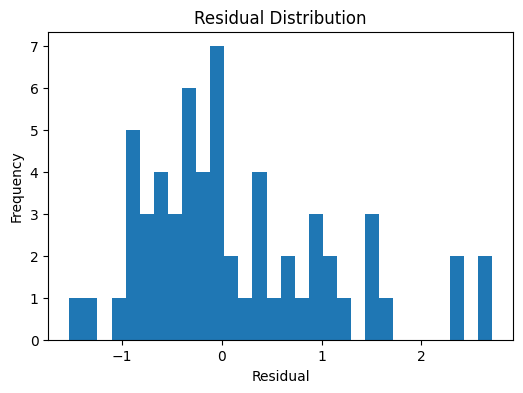

In [ ]:
residuals = y_test - y_test_pred_mean

plt.figure(figsize=(6, 4))

plt.hist(residuals, bins=30)

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

#### Posterior Predictive Check

The predictive distributions broadly align with the observed data in the central region, indicating that the model captures the overall structure of the housing price distribution.

However, discrepancies are evident in the tails, particularly for higher values. The model tends to underestimate extreme housing prices, producing smoother distributions with less mass in the upper range.

This suggests that while the Gaussian Process captures large-scale spatial trends, it lacks the flexibility to model sharp variations and extreme values. This limitation is expected given that only spatial features (latitude and longitude) are used in the model.

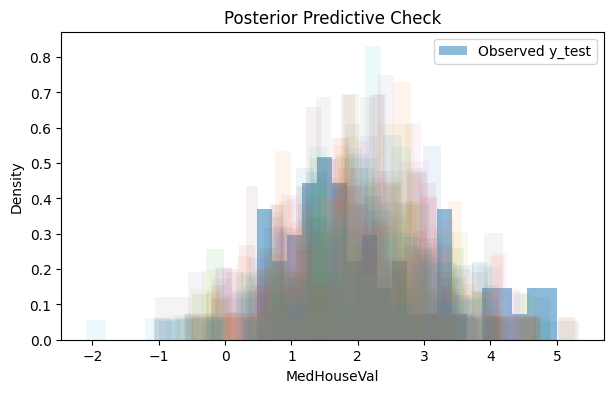

In [ ]:
# a few posterior predictive draws and transform back
num_draws_to_plot = 30
draw_indices = np.random.choice(y_test_rep.shape[0], size=num_draws_to_plot, replace=False)

plt.figure(figsize=(7, 4))
plt.hist(y_test, bins=20, alpha=0.5, density=True, label='Observed y_test')

for idx in draw_indices:
    y_rep_original = y_test_rep[idx] * y_std + y_mean
    plt.hist(y_rep_original, bins=20, alpha=0.08, density=True)

plt.xlabel('MedHouseVal')
plt.ylabel('Density')
plt.title('Posterior Predictive Check')
plt.legend()
plt.show()

### Heatmap

In [ ]:
# create a grid
lon_min, lon_max = df['Longitude'].min(), df['Longitude'].max()
lat_min, lat_max = df['Latitude'].min(), df['Latitude'].max()

lon_grid = np.linspace(lon_min, lon_max, 80)
lat_grid = np.linspace(lat_min, lat_max, 80)

lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

X_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])

In [ ]:
# standardize
X_grid_scaled = x_scaler.transform(X_grid)

In [ ]:
# get the values

# Posterior mean hyperparameters
alpha = 0.918281
rho = 0.389081
sigma = 0.772572
jitter = 1e-5

# Training data in standardized scale
Xtr = X_train_scaled
ytr = y_train_scaled

# Grid data in standardized scale
Xte = X_grid_scaled

def rbf_kernel(X1, X2, alpha, rho):
    # Squared Euclidean distance matrix
    sqdist = (
        np.sum(X1**2, axis=1)[:, None]
        + np.sum(X2**2, axis=1)[None, :]
        - 2 * X1 @ X2.T
    )
    return (alpha**2) * np.exp(-0.5 * sqdist / (rho**2))

# Covariance blocks
K = rbf_kernel(Xtr, Xtr, alpha, rho)
K += (sigma**2 + jitter) * np.eye(len(Xtr))

K_s = rbf_kernel(Xtr, Xte, alpha, rho)
K_ss = rbf_kernel(Xte, Xte, alpha, rho)
K_ss += jitter * np.eye(len(Xte))

# Solve for predictive mean
K_inv_y = np.linalg.solve(K, ytr)
f_mean_scaled = K_s.T @ K_inv_y

# Predictive covariance
K_inv_Ks = np.linalg.solve(K, K_s)
f_cov_scaled = K_ss - K_s.T @ K_inv_Ks

# Convert back to original scale
f_mean = f_mean_scaled * y_std + y_mean
f_sd = np.sqrt(np.clip(np.diag(f_cov_scaled), 0, None)) * y_std

mean_map = f_mean.reshape(lat_mesh.shape)
sd_map = f_sd.reshape(lat_mesh.shape)

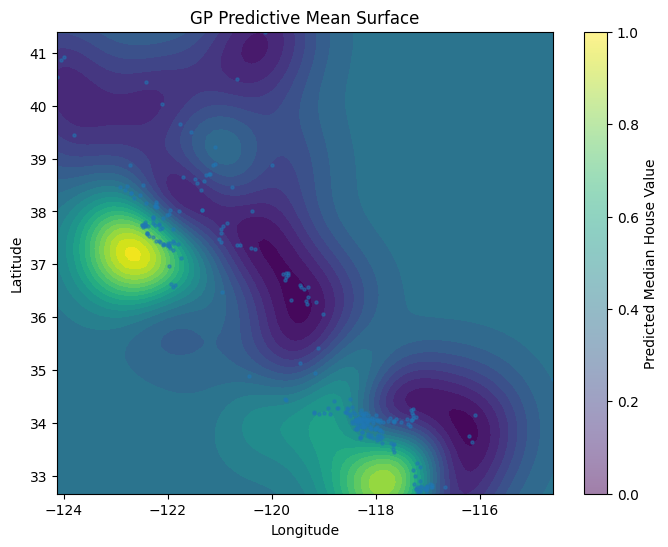

In [ ]:
# Predictive Mean Surface heatmap
plt.figure(figsize=(8, 6))

plt.contourf(lon_mesh, lat_mesh, mean_map, levels=30)
plt.scatter(df['Longitude'], df['Latitude'], s=5, alpha=0.5)

plt.colorbar(label='Predicted Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('GP Predictive Mean Surface')
plt.show()

The GP predictive mean surface reveals a smooth, non-linear spatial structure in housing prices across California. High-value regions are concentrated around major urban areas, such as the Bay Area and Southern California, indicating strong spatial dependence.

The smooth transitions between regions reflect the properties of the RBF kernel, which enforces local continuity in the latent function.

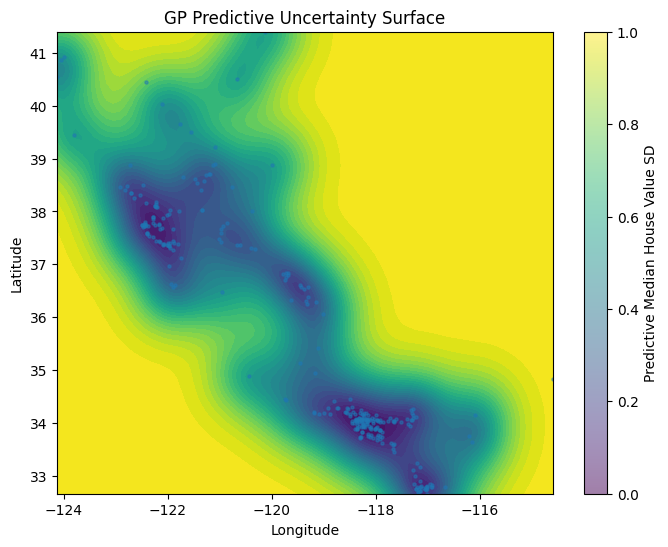

In [ ]:
# Uncertainty heatmap
plt.figure(figsize=(8, 6))

plt.contourf(lon_mesh, lat_mesh, sd_map, levels=30)
plt.scatter(df['Longitude'], df['Latitude'], s=5, alpha=0.5)

plt.colorbar(label='Predictive Median House Value SD')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('GP Predictive Uncertainty Surface')
plt.show()

The predictive uncertainty surface shows that uncertainty is lowest in regions with dense observations and increases in areas with sparse or no data. This reflects the Bayesian nature of the Gaussian Process, which naturally quantifies uncertainty based on data availability.

In particular, boundary regions and areas far from observed locations exhibit significantly higher uncertainty, indicating that predictions in these regions should be interpreted with caution.